In [2]:
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv('alfagift_scrape.csv')

# 2. Cek 5 baris pertama (Biar tau bentuk datanya kayak gimana)
print("--- PREVIEW DATA ---")
display(df.head())

# 3. Cek tipe data dan jumlah baris (Biar tau ada data yang kosong atau formatnya aneh)
print("\n--- INFO DATA ---")
df.info()

# 4. Cek total missing values per kolom
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

--- PREVIEW DATA ---


,Unnamed: 0,Category,Subcategory,product,price
0,0,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Alfamart Sedotan Plastik Flexibel 50 pcs,10.900
1,1,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Alfamart Sarung Tangan Plastik 100 pcs,14.500
2,2,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Alfamart Piring Plastik 20 pcs,19.100
3,3,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Bright Tabung Gas Elpiji (Kosong) 5.5 kg,330.000
4,4,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,SGI Botol Minum Warna Warni Assorted 530 ml,29.900



--- INFO DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9433 entries, 0 to 9432
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   9433 non-null   int64 
 1   Category     9433 non-null   object
 2   Subcategory  9433 non-null   object
 3   product      9433 non-null   object
 4   price        8007 non-null   object
dtypes: int64(1), object(4)
memory usage: 368.6+ KB

--- MISSING VALUES ---
Unnamed: 0        0
Category          0
Subcategory       0
product           0
price          1426
dtype: int64


In [3]:
# 1. Buang kolom Unnamed 0
df = df.drop(columns=['Unnamed: 0'])

# 2. Operasi Pembersihan Kolom Harga
print("Membersihkan teks harga menjadi angka...")
df['price'] = df['price'].astype(str).str.replace('.', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 3. Buang 1.426 baris yang harganya kosong (NaN)
print(f"Jumlah baris sebelum dibersihkan: {len(df)}")
df_clean = df.dropna(subset=['price']).copy()
print(f"Jumlah baris setelah dibersihkan: {len(df_clean)}")

# 4. Standarisasi nama produk untuk persiapan AI nanti
df_clean['product_clean'] = df_clean['product'].str.lower().str.strip()

print("\n--- PREVIEW DATA BERSIH ---")
display(df_clean[['product_clean', 'price', 'Subcategory']].head())

Membersihkan teks harga menjadi angka...
Jumlah baris sebelum dibersihkan: 9433
Jumlah baris setelah dibersihkan: 8007

--- PREVIEW DATA BERSIH ---


,product_clean,price,Subcategory
0,alfamart sedotan plastik flexibel 50 pcs,10900.0,Perlengkapan Dapur & Ruang Makan
1,alfamart sarung tangan plastik 100 pcs,14500.0,Perlengkapan Dapur & Ruang Makan
2,alfamart piring plastik 20 pcs,19100.0,Perlengkapan Dapur & Ruang Makan
3,bright tabung gas elpiji (kosong) 5.5 kg,330000.0,Perlengkapan Dapur & Ruang Makan
4,sgi botol minum warna warni assorted 530 ml,29900.0,Perlengkapan Dapur & Ruang Makan


In [4]:
# Mengambil daftar subkategori unik
unique_subcats = df_clean['Subcategory'].unique()

print(f"Total ada {len(unique_subcats)} subkategori unik di data kita.\n")
print("Ini daftarnya:")
for i, sub in enumerate(unique_subcats, start=1):
    print(f"{i}. {sub}")

Total ada 50 subkategori unik di data kita.

Ini daftarnya:
1. Perlengkapan Dapur & Ruang Makan
2. Bahan Masakan
3. Bahan Roti & Kue
4. Bahan Puding & Agar-Agar
5. Makanan Bayi & Anak
6. Susu Formula Bayi & Anak
7. Perlengkapan Mandi & Perawatan Anak
8. Susu Ibu Hamil & Menyusui
9. Popok Bayi & Anak
10. Pembersih Pakaian & Perlengkapan Anak
11. Perlengkapan Makan & Minum Anak
12. Kebutuhan Ibu, Bayi, & Anak Lainnya
13. Perlengkapan Kamar Mandi
14. Perawatan & Pembersih
15. Perlengkapan Rumah
16. Tisu
17. Pengharum Ruangan & Anti Lembab
18. Pembasmi Hama & Serangga
19. Makanan Ringan
20. Makanan Instan
21. Roti, Selai, & Sereal
22. Minuman Ringan
23. Produk Olahan Susu
24. Minuman Instan
25. Makanan Siap Saji
26. Minuman Siap Saji
27. Makanan Segar
28. Makanan Beku
29. Es Krim
30. Makanan Kemasan
31. Peralatan Rias & Tata Rambut
32. Perawatan Tubuh
33. Perawatan Pria
34. Perawatan Rambut
35. Perawatan Wajah
36. Riasan Wajah & Tubuh
37. Pembalut & Popok Dewasa
38. Perawatan Gigi & Mulut


In [5]:
# 1. Dictionary Mapping Hasil Diskusi Tim
master_mapping = {
    # --- NEEDS: Makan & Minum Harian ---
    'Bahan Masakan': 'Makan & Minum Harian',
    'Bahan Roti & Kue': 'Makan & Minum Harian',
    'Bahan Puding & Agar-Agar': 'Makan & Minum Harian',
    'Makanan Instan': 'Makan & Minum Harian',
    'Roti, Selai, & Sereal': 'Makan & Minum Harian',
    'Produk Olahan Susu': 'Makan & Minum Harian',
    'Minuman Instan': 'Makan & Minum Harian',
    'Makanan Siap Saji': 'Makan & Minum Harian',
    'Minuman Siap Saji': 'Makan & Minum Harian',
    'Makanan Segar': 'Makan & Minum Harian',
    'Makanan Beku': 'Makan & Minum Harian',
    'Makanan Kemasan': 'Makan & Minum Harian',
    'Makanan Bayi & Anak': 'Makan & Minum Harian',
    'Susu Formula Bayi & Anak': 'Makan & Minum Harian',
    'Susu Ibu Hamil & Menyusui': 'Makan & Minum Harian',

    # --- NEEDS: Kebutuhan Rumah & Mandi ---
    'Perlengkapan Dapur & Ruang Makan': 'Kebutuhan Rumah & Mandi',
    'Perlengkapan Kamar Mandi': 'Kebutuhan Rumah & Mandi',
    'Perawatan & Pembersih': 'Kebutuhan Rumah & Mandi',
    'Perlengkapan Rumah': 'Kebutuhan Rumah & Mandi',
    'Tisu': 'Kebutuhan Rumah & Mandi',
    'Pengharum Ruangan & Anti Lembab': 'Kebutuhan Rumah & Mandi',
    'Pembasmi Hama & Serangga': 'Kebutuhan Rumah & Mandi',
    'Perawatan Tubuh': 'Kebutuhan Rumah & Mandi',
    'Perawatan Pria': 'Kebutuhan Rumah & Mandi',
    'Perawatan Rambut': 'Kebutuhan Rumah & Mandi',
    'Pembalut & Popok Dewasa': 'Kebutuhan Rumah & Mandi',
    'Perawatan Gigi & Mulut': 'Kebutuhan Rumah & Mandi',
    'Obat-Obatan': 'Kebutuhan Rumah & Mandi',
    'Alat Kesehatan': 'Kebutuhan Rumah & Mandi',
    'Produk Higienis': 'Kebutuhan Rumah & Mandi',
    'Perlengkapan Mandi & Perawatan Anak': 'Kebutuhan Rumah & Mandi',
    'Pembersih Pakaian & Perlengkapan Anak': 'Kebutuhan Rumah & Mandi',
    'Perlengkapan Makan & Minum Anak': 'Kebutuhan Rumah & Mandi',
    'Kebutuhan Ibu, Bayi, & Anak Lainnya': 'Kebutuhan Rumah & Mandi',
    'Popok Bayi & Anak': 'Kebutuhan Rumah & Mandi',

    # --- WANTS: Jajan & Nongkrong ---
    'Makanan Ringan': 'Jajan & Nongkrong',
    'Minuman Ringan': 'Jajan & Nongkrong',
    'Es Krim': 'Jajan & Nongkrong',

    # --- WANTS: Hobi & Self-Reward ---
    'Peralatan Rias & Tata Rambut': 'Hobi & Self-Reward',
    'Perawatan Wajah': 'Hobi & Self-Reward',
    'Riasan Wajah & Tubuh': 'Hobi & Self-Reward',
    'Parfum & Cologne': 'Hobi & Self-Reward',
    'Mainan & Hiburan': 'Hobi & Self-Reward',
    'Fashion': 'Hobi & Self-Reward',
    'Makanan Anjing': 'Hobi & Self-Reward',
    'Makanan Kucing': 'Hobi & Self-Reward',
    'Makanan Hewan Peliharan Lainnya': 'Hobi & Self-Reward',

    # --- OTHERS: Lain-lain & Darurat ---
    'Vitamin & Suplemen': 'Lain-lain & Darurat',
    'Perlengkapan Kantor & Sekolah': 'Lain-lain & Darurat',
    'Perlengkapan Otomotif': 'Lain-lain & Darurat'
}

# 2. Eksekusi Mapping ke Kolom Baru
df_clean['Master_Category'] = df_clean['Subcategory'].map(master_mapping)

# 3. Validasi: Apakah ada yang terlewat?
lupa_dimap = df_clean[df_clean['Master_Category'].isnull()]['Subcategory'].unique()

if len(lupa_dimap) > 0:
    print("❌ WARNING! Ada kategori yang belum masuk ke kamus mapping:")
    print(lupa_dimap)
else:
    print("✅ AMAN! Semua 50 Subkategori sudah berhasil dipetakan ke Master Category.")

    # 4. Tambahkan Macro Category (Top Level)
    macro_mapping = {
        'Makan & Minum Harian': 'NEEDS',
        'Kebutuhan Rumah & Mandi': 'NEEDS',
        'Jajan & Nongkrong': 'WANTS',
        'Hobi & Self-Reward': 'WANTS',
        'Lain-lain & Darurat': 'OTHERS'
    }
    df_clean['Macro_Category'] = df_clean['Master_Category'].map(macro_mapping)

    # 5. Rapikan urutan kolom dan Simpan ke CSV baru
    kolom_final = ['product_clean', 'price', 'Macro_Category', 'Master_Category', 'Subcategory', 'Category']
    df_final = df_clean[kolom_final]

    # Simpan hasil akhirnya
    nama_file_baru = 'alfagift_final_dataset.csv'
    df_final.to_csv(nama_file_baru, index=False)

    print(f"\n📁 Selesai! Data final (sebanyak {len(df_final)} baris) telah disimpan sebagai '{nama_file_baru}'")

    # Tampilkan 5 sampel data acak untuk melihat hasilnya
    print("\n--- PREVIEW HASIL AKHIR ---")
    display(df_final.sample(5))

✅ AMAN! Semua 50 Subkategori sudah berhasil dipetakan ke Master Category.

📁 Selesai! Data final (sebanyak 8007 baris) telah disimpan sebagai 'alfagift_final_dataset.csv'

--- PREVIEW HASIL AKHIR ---


,product_clean,price,Macro_Category,Master_Category,Subcategory,Category
2838,regal biskuit marie superior 230 g,25500.0,WANTS,Jajan & Nongkrong,Makanan Ringan,Makanan
4802,teh gelas original 350 ml,2800.0,WANTS,Jajan & Nongkrong,Minuman Ringan,Minuman
5572,sidomuncul este emje ginseng minuman tradision...,23500.0,NEEDS,Makan & Minum Harian,Minuman Instan,Minuman
6419,biore sabun mandi cair relaxing aromatic 100 ml,15000.0,NEEDS,Kebutuhan Rumah & Mandi,Perawatan Tubuh,Personal Care
8651,enervon-c multivitamin suplemen daya tahan tub...,7800.0,OTHERS,Lain-lain & Darurat,Vitamin & Suplemen,Kebutuhan Kesehatan


/tmp/ipykernel_5475/855662948.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=master_counts.values, y=master_counts.index, palette="viridis")


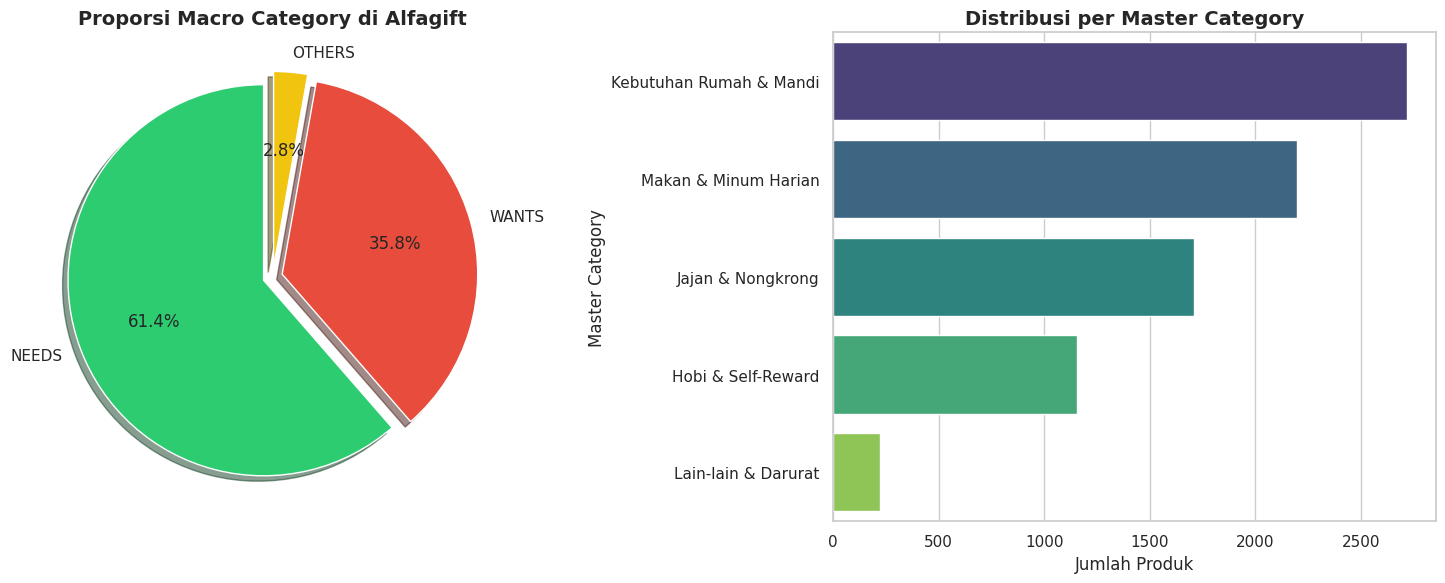

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data final yang baru saja kita buat
df_final = pd.read_csv('alfagift_final_dataset.csv')

# Set style untuk grafiknya biar estetik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# ==========================================
# GRAFIK 1: Pie Chart (Proporsi Needs vs Wants)
# ==========================================
plt.subplot(1, 2, 1)
macro_counts = df_final['Macro_Category'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f1c40f'] # Hijau (Needs), Merah (Wants), Kuning (Others)
explode = (0.05, 0.05, 0.05) # Efek pecah sedikit biar keren

plt.pie(macro_counts, labels=macro_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode[:len(macro_counts)], shadow=True)
plt.title('Proporsi Macro Category di Alfagift', fontweight='bold', fontsize=14)

# ==========================================
# GRAFIK 2: Bar Chart (Top Master Category)
# ==========================================
plt.subplot(1, 2, 2)
master_counts = df_final['Master_Category'].value_counts().sort_values(ascending=False)

sns.barplot(x=master_counts.values, y=master_counts.index, palette="viridis")
plt.title('Distribusi per Master Category', fontweight='bold', fontsize=14)
plt.xlabel('Jumlah Produk')
plt.ylabel('Master Category')

# Tampilkan grafiknya!
plt.tight_layout()
plt.show()